<a href="https://colab.research.google.com/github/suraj021103-hash/demo/blob/main/Sales%20Data%20Analysis%20and%20Visualization%20using%20SQL%20and%20Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving customers.csv to customers.csv
Saving order_details.csv to order_details.csv
Saving orders.csv to orders.csv
Saving products.csv to products.csv


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
customers = pd.read_csv('customers.csv')
orders = pd.read_csv('orders.csv')
products = pd.read_csv('products.csv')
order_details = pd.read_csv('order_details.csv')

In [4]:
print(customers.columns)
print(orders.columns)
print(products.columns)
print(order_details.columns)

Index(['customer_id', 'name', 'city'], dtype='object')
Index(['order_id', 'customer_id', 'order_date'], dtype='object')
Index(['product_id', 'product_name', 'price'], dtype='object')
Index(['order_id', 'product_id', 'quantity'], dtype='object')


In [5]:
df = orders.merge(order_details, on='order_id') \
           .merge(products, on='product_id') \
           .merge(customers, on='customer_id')

In [6]:
print(df.head())

   order_id  customer_id  order_date  product_id  quantity product_name  \
0       101            1  2024-01-10           1         1       Laptop   
1       101            1  2024-01-10           3         2   Headphones   
2       102            2  2024-02-15           2         1        Phone   
3       103            1  2024-03-05           1         1       Laptop   
4       103            1  2024-03-05           2         1        Phone   

   price   name     city  
0  50000  Suraj  Chennai  
1   2000  Suraj  Chennai  
2  20000  Rahul    Delhi  
3  50000  Suraj  Chennai  
4  20000  Suraj  Chennai  


In [7]:
df['revenue'] = df['price'] * df['quantity']

In [8]:
print("Total Revenue:", df['revenue'].sum())

Total Revenue: 144000


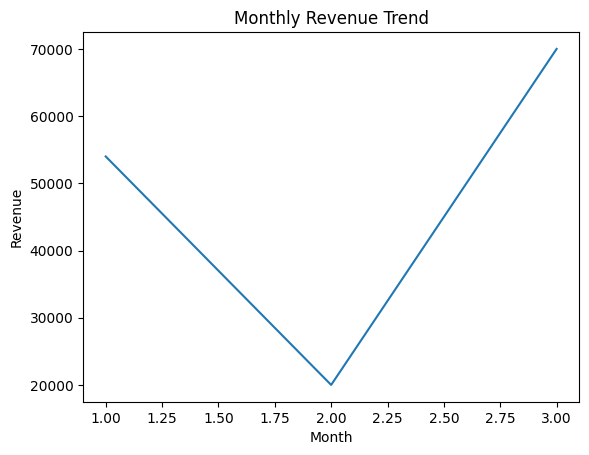

In [9]:
import matplotlib.pyplot as plt

df['order_date'] = pd.to_datetime(df['order_date'])

monthly = df.groupby(df['order_date'].dt.month)['revenue'].sum()

monthly.plot(kind='line')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.show()

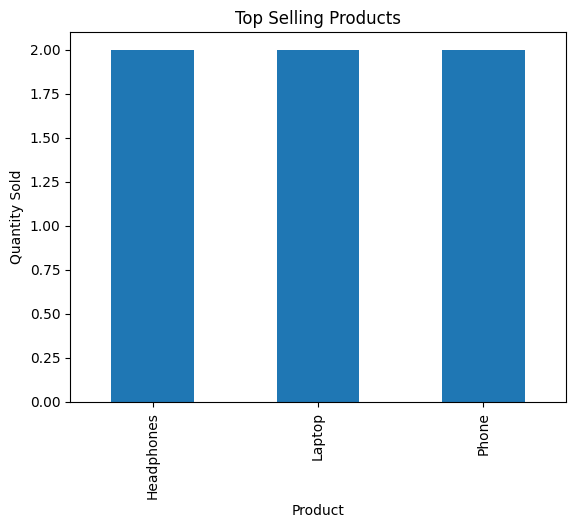

In [10]:
top_products = df.groupby('product_name')['quantity'].sum()

top_products.plot(kind='bar')
plt.title('Top Selling Products')
plt.xlabel('Product')
plt.ylabel('Quantity Sold')
plt.show()

In [11]:
top_customers = df.groupby('name')['revenue'].sum().sort_values(ascending=False)

print(top_customers)

name
Suraj    124000
Rahul     20000
Name: revenue, dtype: int64


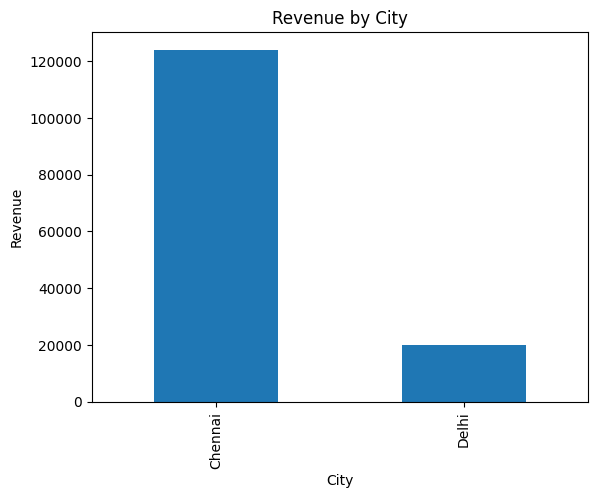

In [12]:
city_revenue = df.groupby('city')['revenue'].sum()

city_revenue.plot(kind='bar')
plt.title('Revenue by City')
plt.xlabel('City')
plt.ylabel('Revenue')
plt.show()

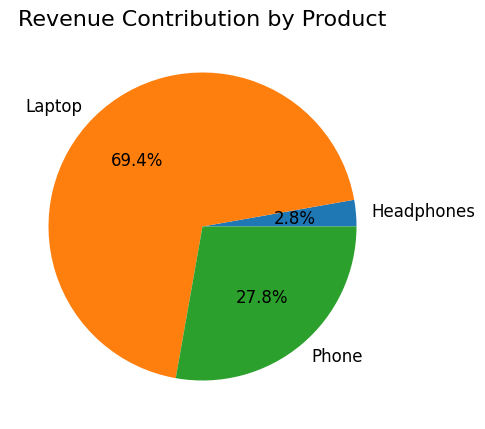

In [15]:
product_revenue = df.groupby('product_name')['revenue'].sum()

plt.figure()
plt.pie(product_revenue, labels=product_revenue.index, autopct='%1.1f%%')

plt.title('Revenue Contribution by Product', fontsize=16)
plt.show()

In [16]:
df['order_date'] = pd.to_datetime(df['order_date'])

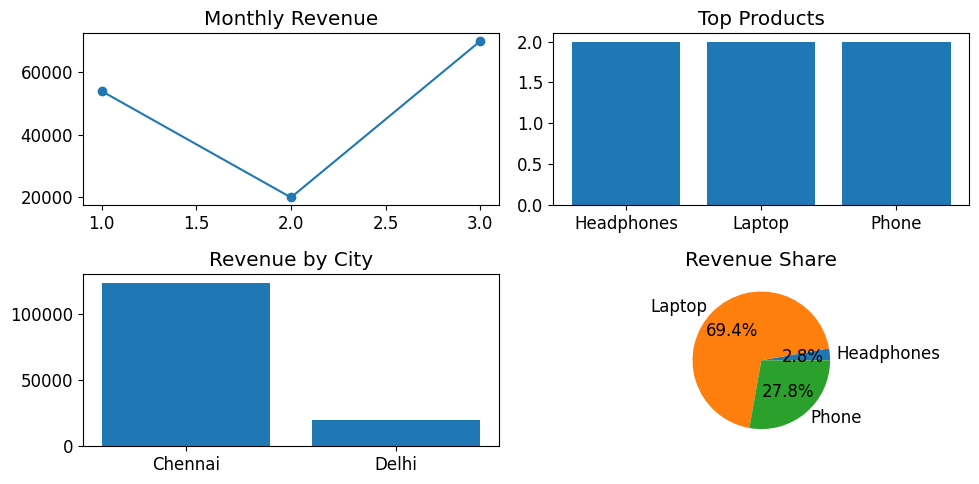

In [17]:
fig, axes = plt.subplots(2, 2)

# 🔹 1. Monthly Revenue
monthly = df.groupby(df['order_date'].dt.month)['revenue'].sum().sort_index()
axes[0,0].plot(monthly.index, monthly.values, marker='o')
axes[0,0].set_title('Monthly Revenue')

# 🔹 2. Top Products
top_products = df.groupby('product_name')['quantity'].sum()
axes[0,1].bar(top_products.index, top_products.values)
axes[0,1].set_title('Top Products')

# 🔹 3. Revenue by City
city_revenue = df.groupby('city')['revenue'].sum()
axes[1,0].bar(city_revenue.index, city_revenue.values)
axes[1,0].set_title('Revenue by City')

# 🔹 4. Pie Chart
product_revenue = df.groupby('product_name')['revenue'].sum()
axes[1,1].pie(product_revenue, labels=product_revenue.index, autopct='%1.1f%%')
axes[1,1].set_title('Revenue Share')

plt.tight_layout()
plt.show()